In [1]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
import os
import pandas as pd
from datetime import datetime

os.chdir('../src/')


from prop_elem import *
from sbdynt import *

# Default Proper Element Run

Default properties for computing proper elements for TNOs is contained within the same ``run_tno`` function used to initialize and run the machine learning algorithm for TNO resonance occupation.
A similar function, ``run_asteroid`` can be used to similarly run and compute proper elements for asteroids. We demonstrate these functions below for TNO (15760) Albion and the dwarf planet and asteroid (1) Ceres. 

To compute proper elements as well, from the ``run_tno`` function, user should set the boolean variable ``run_proper = True``, which will compute the proper elements and save the results to the ``tno_result`` output. 

The bulk of the time required by these functions is actually spent integrating the simulation, or if the simulation is already integrated, in reading the orbital elements from the Simulation Archive binary files. The actual computation of the proper elements is comparatively fast.

In this TNO example, we will still run the machine learning algorithm by including ``run_ML = True``, as this produces a more complex Simulation Archive with varying time resolution. This demonstrates how these complex archives are automatically handled while computing the proper elements from the simulation. We also include print statements to demonstrate and benchmark how long the default runs may take to fully integrate. 

In [2]:
begin = datetime.now()

objname = 'Arrokoth'
objname = '2011 UJ411'
#tno_result = run_tno(des='2011 UJ411', clones=10, 
#                     datadir='../example-notebooks/example_sims',
#                     archivefile=None, logfile=False,deletefile=True, 
#                     run_ML = True, run_proper=True, run_chaos = True)

tno_result = run_existing_tno(des=objname, clones=10, 
                     datadir='../example-notebooks/example_sims',
                     archivefile=None, logfile=False,deletefile=True, 
                     run_ML = True, run_proper=True, run_chaos = True)
print(datetime.now() - begin)

Running TNO ML
run and ML classify
Reading TNO integration for Proper Elements and/or Chaos
Running TNO Proper Elements
Running TNO Chaos Indicators
0:03:44.177999


In [3]:
pe = tno_result.proper_elements
ml = tno_result.tno_ml_outputs
ci = tno_result.chaos_indicators

In [4]:
print(ml.print_results())
print(vars(ci))
print(dir(ml))

print('Proper Elements')
print(pe.proper_elements)

#Most common classification: Nresonant
#Shared by 100.000000 percent of clones
#
#Clone number, most probable G08 class, p, q, m, n, phi_std, phi_delta, res_image_prob, probability of that class, probability of Nresonant, scattering, class-det, 
0, Nresonant, 5, 3, 2, 0, 1.794853e-01, 8.920924e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 3.330015e-12, 8.971358e-10, 
1, Nresonant, 5, 3, 2, 0, 1.669062e-01, 8.543962e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 3.664942e-12, 1.452158e-09, 
2, Nresonant, 5, 3, 2, 0, 1.753198e-01, 8.693793e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 2.966793e-12, 1.039311e-09, 
3, Nresonant, 5, 3, 2, 0, 1.704017e-01, 8.720016e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 3.415990e-12, 1.053753e-09, 
4, Nresonant, 5, 3, 2, 0, 1.937917e-01, 9.060858e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 2.440565e-12, 7.270676e-10, 
5, Nresonant, 5, 3, 2, 0, 1.770827e-01, 8.838952e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 3.367937e-12, 1.160074e-09, 
6, N

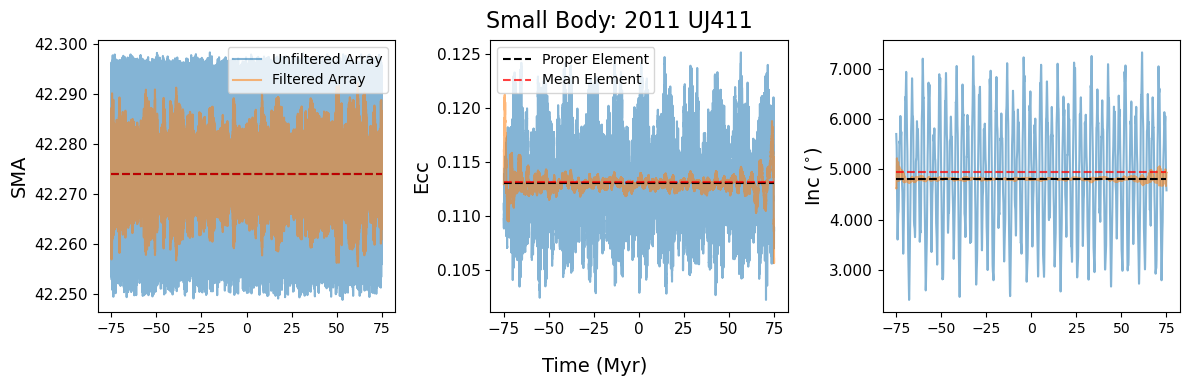

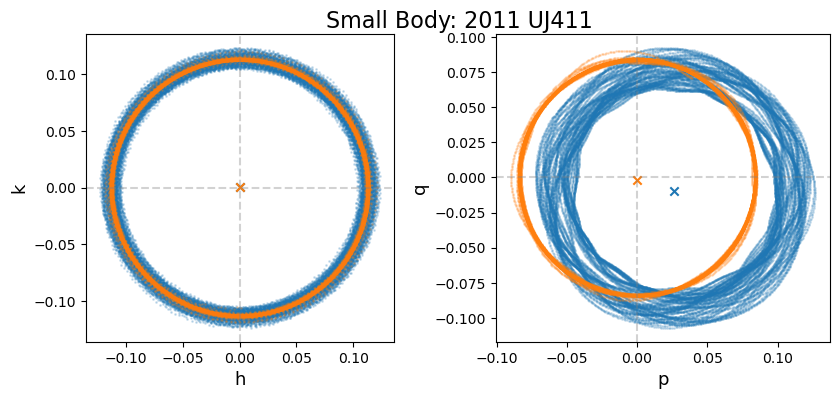

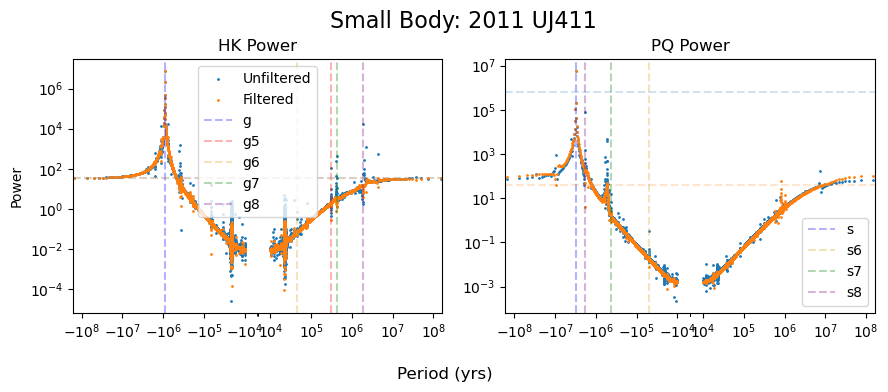

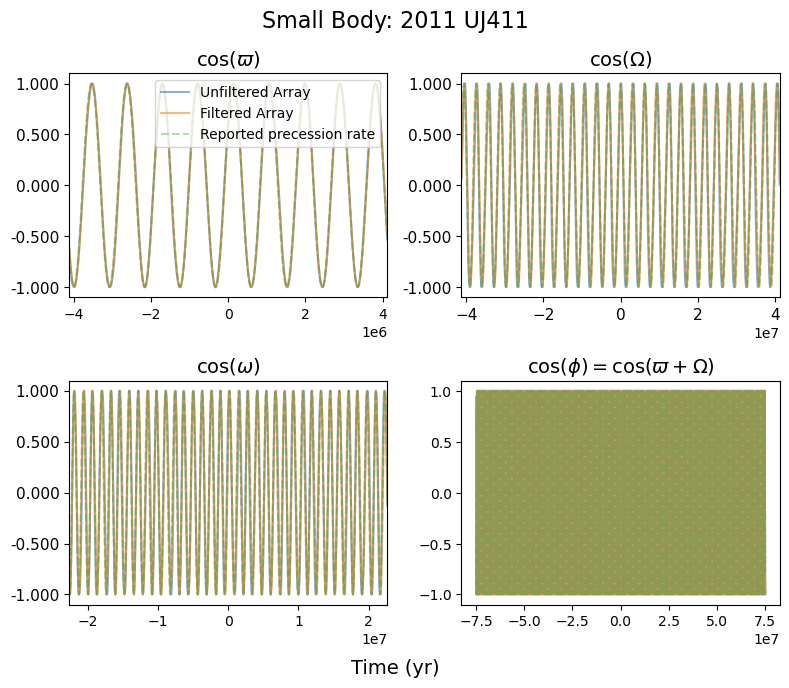

In [5]:
pe.plot_time_arrays()
pe.plot_hkpq()
pe.plot_freq_space('1')
pe.plot_angles(plot_cos=True)

In [2]:
begin = datetime.now()
ast_result = run_ast(des='1', clones=1, datadir='../example-notebooks/example_sims',archivefile=None, logfile=False,deletefile=False, run_proper=True)
print(datetime.now() - begin)

Running Asteroid integration for Proper Elements
Reading Asteroid integration
Running Asteroid Proper Elements
0:19:46.199225


Functions are also provided to use an existing Simulation archive for a TNO or asteroid to comptue the proper elements from that archive file, which bypasses the need to reintegrate the entire small body.

An archive file that is not computed using SBDynT may be used, if it has the appropriate planets for the object, with the correct hashes as identifiers, and if the proper ``object_type`` is specified. However, we recommend typically implementing these functions only with archive files produced using SBDynT code, as formatting differences may occur. 

Since we have already integrated Simulation archives above for TNO ``(15760) Albion`` and asteroid ``(1) Ceres``, we may use these functions to more quickly compute the proper elements for these objects.

In [3]:
begin = datetime.now()
tno_result = run_existing_tno(des='15760', clones=1, datadir='../example-notebooks/example_sims/',archivefile=None,
                                     logfile=False,deletefile=False, run_ML = False, run_proper=True, output_arrays = True)
print(datetime.now()-begin)


begin = datetime.now()
ast_result = run_existing_sb(des='1', clones=1, datadir='../example-notebooks/example_sims/',archivefile=None, object_type='asteroid',
                                     logfile=False,deletefile=False, run_proper=True, output_arrays = True)
print(datetime.now()-begin)

Reading TNO integration for Proper Elements and/or Chaos
Running TNO Proper Elements
0:00:22.755919
object_type is neither asteroid or tno. Setting default tmax = 50 Myr.
object_type is neither asteroid or tno. Setting default tout = 2000 yr.
object_type is neither asteroid or tno. Setting default planets = ["outer"]
Reading Small Body integration
Running TNO PE
0:00:58.860320


# Proper Element Outputs

The proper element results are saved to a ``proper_element`` class object within the ``tno_result`` object. 
This class object contains a large number of relevant values and indicators related to the orbital evolution of the small body corresponding to the proper motion over time. These include...

```proper_elements```

```mean_elements```

```osculating_elements```

```proper_errors```

```planet_freqs```

```proper_windows```

### Proper Elements

The proper elements themselves are contained in a dictionary with the same name as the ``proper_element`` class. These can be contrasted with the mean elements, (which are simply the mean of the osculating element time array), and the initial osculating elements, (which represent the orbital elements at time ``t=0`` in the simulation).

We note that these mean elements are not be confused with the ``mean`` indicator, which is used to identify objects which experience chaotic motion or long-term periodic evolution such that the synethic proper element cannot be accurately computed for the small-body in the given integration. 
We will discuss the ``mean`` indicator, as well as other useful indicators, in more detail in the ``proper_elements_advanced`` notebook. 

These three outputs contain the semi-major axis, eccentricity, inclination, as well as the proper and mean precession rates, ``g`` and ``s``, in the case of the ``proper_elements`` and ``mean_elements`` variables. The ``osculating_elements`` variable instead reports the initial ``omega`` and ``Omega`` values at the ``t=0`` epoch.

The proper and mean ``g`` and ``s`` frequencies are reported in both revolutions/year (the units of measurement used by the filtering, the direct result from the filter) and arcseconds/year (the typically reported value for the proper precession rates).

In [4]:
print('Albion: ',tno_result.proper_elements.proper_elements)
print('\nCeres:', ast_result.proper_elements.proper_elements)


Albion:  {'a': 43.928935681494146, 'e': 0.07043448373459142, 'sinI': 0.04440112820221604, 'g(rev/yr)': 3.2035337683703504e-07, 's(rev/yr)': -3.245606741083782e-07, 'g("/yr)': 0.4151779763807974, 's("/yr)': -0.42063063364445813}

Ceres: {'a': 2.763406515668239, 'e': 0.11501356400336549, 'sinI': 0.16749147584301236, 'g(rev/yr)': 4.188877410733603e-05, 's(rev/yr)': -4.570035942896296e-05, 'g("/yr)': 54.28785124310749, 's("/yr)': -59.22766581993599}


In [5]:
print('Albion:', tno_result.proper_elements.mean_elements)
print('\nCeres:', ast_result.proper_elements.mean_elements)

Albion: {'a': 43.928935681494146, 'e': 0.07061951784780847, 'sinI': 0.04937405303162945, 'g(rev/yr)': 3.172197229593871e-07, 's(rev/yr)': -2.4756116644647855e-07, 'g("/yr)': 0.41111676095536565, 's("/yr)': -0.32083927171463617}

Ceres: {'a': 2.763406515668238, 'e': 0.11807830194545915, 'sinI': 0.16882018760934106, 'g(rev/yr)': 3.9446182755905544e-05, 's(rev/yr)': -4.382241912399143e-05, 'g("/yr)': 51.122252851653585, 's("/yr)': -56.7938551846929}


In [6]:
print('Albion:',tno_result.proper_elements.osculating_elements)
print('\nCeres:',ast_result.proper_elements.osculating_elements)

Albion: {'a': array([43.93250143]), 'e': array([0.06937744]), 'I': array([0.03814445]), 'o': array([0.04935982]), 'O': array([-0.01023984])}

Ceres: {'a': array([2.74688581]), 'e': array([0.08056522]), 'I': array([0.18510206]), 'o': array([1.23614904]), 'O': array([1.40037391])}


### Proper Element Uncertainties

The proper element uncertainties are contained in the ``proper_errors`` dictionary.

In [7]:
print('Albion:', tno_result.proper_elements.proper_errors)
print('\nCeres:',ast_result.proper_elements.proper_errors)

Albion: {'RMS_a': 3.244117726188717e-05, 'RMS_e': 0.0001934480090940436, 'RMS_sinI': 0.00031783782025829224, 'RMS_g(rev/yr)': 3.216805560630463e-10, 'RMS_s(rev/yr)': 4.1237999983026495e-09, 'RMS_g("/yr)': 0.000416898000657708, 'RMS_s("/yr)': 0.005344444797800233}

Ceres: {'RMS_a': 8.84006673691857e-06, 'RMS_e': 0.00010762550324007103, 'RMS_sinI': 3.979821655704769e-06, 'RMS_g(rev/yr)': 8.018019884734566e-08, 'RMS_s(rev/yr)': 5.349721561278501e-08, 'RMS_g("/yr)': 0.10391353770615998, 'RMS_s("/yr)': 0.06933239143416937}


### Planetary Frequencies

Users interested in the identified planetary secular frequencies can retrieve these from the ``planets`` dictionary. These are only reported in the units of rev/yr. Users can retrieve the "/yr units by multipying these results by 1296000.

In [8]:
print('Albion:', tno_result.proper_elements.planet_freqs)
print('\nCeres:', ast_result.proper_elements.planet_freqs)

Albion: {'g5': 3.273511501319481e-06, 'g6': 2.1787417624085047e-05, 'g7': 2.3813113377703615e-06, 'g8': 5.200178656944962e-07, 's6': -2.0327034851421574e-05, 's7': -2.3095594664273235e-06, 's8': -5.333523252443816e-07}

Ceres: {'g5': 3.2999222666243006e-06, 'g6': 2.1799972548635788e-05, 'g7': 2.3998158233617146e-06, 'g8': 4.999358620998731e-07, 's6': -2.03038604885051e-05, 's7': -2.300005105070441e-06, 's8': -5.060638049212581e-07, 'g2': 5.513626202629028e-06, 'g3': 1.3609004019681211e-05, 'g4': 1.3116802920676387e-05, 's3': -1.4456233703194622e-05, 's4': -1.3697664700069688e-05, 's2': -4.794454843482448e-06}


### Window Proper Elements

Users may also access the proper element computed for each of the windows. This could be useful in cases of objects which experience chaotic or scattering motion, if the users wishes to see the proper element before such events. 

In [9]:
print('Albion:', tno_result.proper_elements.proper_windows)
print('\nCeres:', ast_result.proper_elements.proper_windows)

Albion: {'a_win': array([43.9288928 , 43.92890352, 43.92891234, 43.92893841, 43.92897854]), 'e_win': array([0.07021687, 0.07041104, 0.07037965, 0.07014567, 0.07020473]), 'sinI_win': array([0.04408116, 0.04456206, 0.04433334, 0.04394276, 0.04399848]), 'g_win': array([3.20031076e-07, 3.20035118e-07, 3.20034802e-07, 3.20027846e-07,
       3.20029703e-07]), 's_win': array([-3.20193995e-07, -3.21077705e-07, -3.20745522e-07, -3.20102408e-07,
       -3.20156341e-07])}

Ceres: {'a_win': array([2.76341246, 2.76341751, 2.76341865, 2.76341305, 2.76339986]), 'e_win': array([0.11513864, 0.1151797 , 0.11513   , 0.1150174 , 0.1149804 ]), 'sinI_win': array([0.16749915, 0.1674936 , 0.16749128, 0.16748949, 0.16748805]), 'g_win': array([4.18081801e-05, 4.18085830e-05, 4.18088407e-05, 4.18088639e-05,
       4.18085038e-05]), 's_win': array([-4.57706028e-05, -4.57616194e-05, -4.57481696e-05, -4.57419443e-05,
       -4.57404559e-05])}


More advanced outputs are further discussed in the ``proper_elements_advanced.ipynb`` file, which include flags related to chaos, the amplitude of secular terms, as well as some indicators which may be hekpful for identifying secualr resonance occupation. 